1.Porblem statment
2.Reasearch Questions
3. Objectives


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')




In [4]:
df=pd.read_csv("/content/2017_Green_Taxi_Trip_Data.csv")

In [3]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type
0,2,01/01/2017 12:01:15 AM,01/01/2017 12:11:05 AM,N,1.0,42.0,166.0,1.0,1.71,9.0,0.0,0.5,0.00,0.0,NaN,0.3,9.80,2.0,1.0
1,2,01/01/2017 12:03:34 AM,01/01/2017 12:09:00 AM,N,1.0,75.0,74.0,1.0,1.44,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2.0,1.0
2,2,01/01/2017 12:04:02 AM,01/01/2017 12:12:55 AM,N,1.0,82.0,70.0,5.0,3.45,12.0,0.5,0.5,2.66,0.0,NaN,0.3,15.96,1.0,1.0
3,2,01/01/2017 12:01:40 AM,01/01/2017 12:14:23 AM,N,1.0,255.0,232.0,1.0,2.11,10.5,0.5,0.5,0.00,0.0,NaN,0.3,11.80,2.0,1.0
4,2,01/01/2017 12:00:51 AM,01/01/2017 12:18:55 AM,N,1.0,166.0,239.0,1.0,2.76,11.5,0.5,0.5,0.00,0.0,NaN,0.3,12.80,2.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544557 entries, 0 to 544556
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               544557 non-null  int64  
 1   lpep_pickup_datetime   544557 non-null  object 
 2   lpep_dropoff_datetime  544556 non-null  object 
 3   store_and_fwd_flag     544556 non-null  object 
 4   RatecodeID             544556 non-null  float64
 5   PULocationID           544556 non-null  float64
 6   DOLocationID           544556 non-null  float64
 7   passenger_count        544556 non-null  float64
 8   trip_distance          544556 non-null  float64
 9   fare_amount            544556 non-null  float64
 10  extra                  544556 non-null  float64
 11  mta_tax                544556 non-null  float64
 12  tip_amount             544556 non-null  float64
 13  tolls_amount           544556 non-null  float64
 14  ehail_fee              0 non-null   

In [12]:
df["lpep_pickup_datetime"]=pd.to_datetime(df["lpep_pickup_datetime"])
df["lpep_dropoff_datetime"]=pd.to_datetime(df["lpep_dropoff_datetime"])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 483781 entries, 0 to 544555
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               483781 non-null  int64         
 1   lpep_pickup_datetime   483781 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  483781 non-null  datetime64[ns]
 3   store_and_fwd_flag     483781 non-null  object        
 4   RatecodeID             483781 non-null  float64       
 5   PULocationID           483781 non-null  float64       
 6   DOLocationID           483781 non-null  float64       
 7   passenger_count        483781 non-null  float64       
 8   trip_distance          483781 non-null  float64       
 9   fare_amount            483781 non-null  float64       
 10  extra                  483781 non-null  float64       
 11  mta_tax                483781 non-null  float64       
 12  tip_amount             483781 non-null  float64  

In [14]:
df['duration']=df['lpep_dropoff_datetime']-df['lpep_pickup_datetime']
df['duration']=df['duration'].dt.total_seconds()/60

In [ ]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,duration
0,2,2017-01-01 00:01:15,2017-01-01 00:11:05,N,1,42,166,1,1.71,9.0,0.0,0.5,0.00,0.0,NaN,0.3,9.80,2.0,1.0,9.833333
1,2,2017-01-01 00:03:34,2017-01-01 00:09:00,N,1,75,74,1,1.44,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2.0,1.0,5.433333
2,2,2017-01-01 00:04:02,2017-01-01 00:12:55,N,1,82,70,5,3.45,12.0,0.5,0.5,2.66,0.0,NaN,0.3,15.96,1.0,1.0,8.883333
3,2,2017-01-01 00:01:40,2017-01-01 00:14:23,N,1,255,232,1,2.11,10.5,0.5,0.5,0.00,0.0,NaN,0.3,11.80,2.0,1.0,12.716667
4,2,2017-01-01 00:00:51,2017-01-01 00:18:55,N,1,166,239,1,2.76,11.5,0.5,0.5,0.00,0.0,NaN,0.3,12.80,2.0,1.0,18.066667


In [15]:
df=df[["passenger_count","trip_distance","fare_amount","payment_type","duration"]]

In [ ]:
df.shape

(878153, 5)

In [ ]:
df.isnull().sum()

,0
passenger_count,0
trip_distance,0
fare_amount,0
payment_type,1
duration,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(878152, 5)

In [ ]:
df[df.duplicated()].shape

(257460, 5)

In [ ]:
df.drop_duplicates(inplace=True)

In [9]:
df["payment_type"]=df["payment_type"].astype("int64")
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type
0,2,2017-01-01 00:01:15,01/01/2017 12:11:05 AM,N,1.0,42.0,166.0,1.0,1.71,9.0,0.0,0.5,0.00,0.0,NaN,0.3,9.80,2,1.0
1,2,2017-01-01 00:03:34,01/01/2017 12:09:00 AM,N,1.0,75.0,74.0,1.0,1.44,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2,1.0
2,2,2017-01-01 00:04:02,01/01/2017 12:12:55 AM,N,1.0,82.0,70.0,5.0,3.45,12.0,0.5,0.5,2.66,0.0,NaN,0.3,15.96,1,1.0
3,2,2017-01-01 00:01:40,01/01/2017 12:14:23 AM,N,1.0,255.0,232.0,1.0,2.11,10.5,0.5,0.5,0.00,0.0,NaN,0.3,11.80,2,1.0
4,2,2017-01-01 00:00:51,01/01/2017 12:18:55 AM,N,1.0,166.0,239.0,1.0,2.76,11.5,0.5,0.5,0.00,0.0,NaN,0.3,12.80,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544550,2,2017-01-17 08:38:42,01/17/2017 09:10:16 AM,N,1.0,166.0,48.0,1.0,4.60,22.0,0.0,0.5,4.56,0.0,NaN,0.3,27.36,1,1.0
544551,2,2017-01-17 08:59:32,01/17/2017 09:02:45 AM,N,1.0,166.0,166.0,1.0,0.75,4.5,0.0,0.5,1.00,0.0,NaN,0.3,6.30,1,1.0
544552,2,2017-01-17 08:56:25,01/17/2017 09:03:22 AM,N,1.0,223.0,223.0,1.0,1.21,7.0,0.0,0.5,0.00,0.0,NaN,0.3,7.80,2,1.0
544553,2,2017-01-17 08:49:18,01/17/2017 08:52:13 AM,N,1.0,226.0,226.0,1.0,0.46,4.0,0.0,0.5,1.20,0.0,NaN,0.3,7.95,1,1.0


In [ ]:
df.describe()

,passenger_count,trip_distance,fare_amount,payment_type,duration
count,620692.000000,620692.000000,620692.000000,620692.000000,620692.000000
mean,1.501029,3.140853,13.111901,1.503248,24.809709
std,1.198971,3.015057,9.763538,0.532391,119.119478
min,0.000000,0.000000,-180.000000,1.000000,0.000000
25%,1.000000,1.250000,7.000000,1.000000,7.316667
50%,1.000000,2.240000,10.500000,1.000000,11.866667
75%,1.000000,3.990000,16.000000,2.000000,18.350000
max,9.000000,171.650000,536.500000,5.000000,1439.900000


In [ ]:
df=df[df["fare_amount"]>0]
df=df[df["trip_distance"]>0]
df=df[df["duration"]>0]

In [ ]:
df.describe()

,passenger_count,trip_distance,fare_amount,payment_type,duration
count,612148.000000,612148.000000,612148.000000,612148.000000,612148.000000
mean,1.501808,3.172469,13.160605,1.496266,24.899789
std,1.200815,3.006783,9.304851,0.522222,119.177984
min,0.000000,0.010000,0.010000,1.000000,0.016667
25%,1.000000,1.280000,7.000000,1.000000,7.433333
50%,1.000000,2.280000,10.500000,1.000000,11.950000
75%,1.000000,4.000000,16.000000,2.000000,18.416667
max,9.000000,171.650000,536.500000,5.000000,1439.900000


In [8]:
df["passenger_count"].value_counts(normalize=True)
df["payment_type"].value_counts(normalize=True)

,proportion
payment_type,
2.0,0.526298
1.0,0.466360
3.0,0.004717
4.0,0.002584
5.0,0.000041


In [ ]:
df=df[(df['passenger_count']>0)&(df['passenger_count']<6)]
df=df[df["payment_type"]<3]


In [ ]:
df.head()

,passenger_count,trip_distance,fare_amount,payment_type,duration
0,1,1.71,9.0,2,9.833333
1,1,1.44,6.5,2,5.433333
2,5,3.45,12.0,1,8.883333
3,1,2.11,10.5,2,12.716667
4,1,2.76,11.5,2,18.066667


{'whiskers': [<matplotlib.lines.Line2D at 0x7b103361ab70>,
 'caps': [<matplotlib.lines.Line2D at 0x7b103361bb30>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b1033543740>],
 'medians': [<matplotlib.lines.Line2D at 0x7b1033619d90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b10336185f0>],
 'means': []}

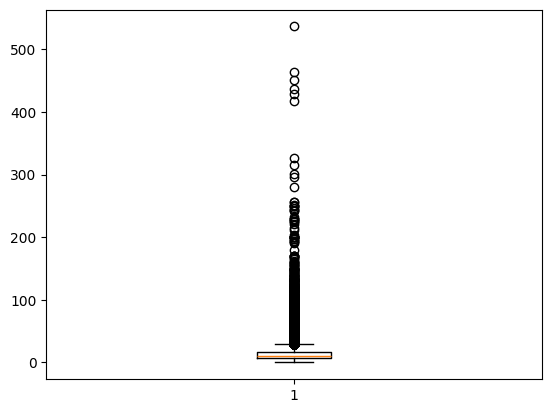

In [ ]:
plt.boxplot(df["fare_amount"])

(array([ 40753., 129499.,  99383.,  66418.,  44738.,  34748.,  25502.,
         18174.,  13802.,  10764.]),
 array([0.   , 0.559, 1.118, 1.677, 2.236, 2.795, 3.354, 3.913, 4.472,
        5.031, 5.59 ]),
 <BarContainer object of 10 artists>)

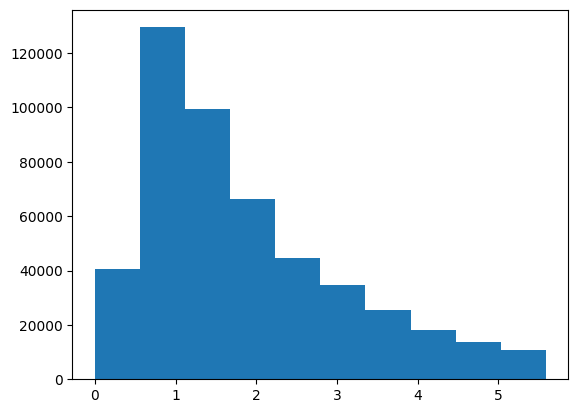

In [7]:
#checking outliers
plt.hist(df["trip_distance"])

In [16]:
#Hnadling outliers
for col in ["fare_amount","trip_distance","duration"]:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  upper_limit=q3+1.5*iqr
  lower_limit=q1-1.5*iqr

  df=df[(df[col]>=lower_limit)&(df[col]<=upper_limit)]




In [17]:
df["payment_type"]=df["payment_type"].replace({1:"Card",2:"Cash"})

In [18]:
df

,passenger_count,trip_distance,fare_amount,payment_type,duration
0,1.0,1.71,9.0,Cash,9.833333
1,1.0,1.44,6.5,Cash,5.433333
2,5.0,3.45,12.0,Card,8.883333
3,1.0,2.11,10.5,Cash,12.716667
4,1.0,2.76,11.5,Cash,18.066667
...,...,...,...,...,...
544549,1.0,0.45,4.5,Cash,3.416667
544551,1.0,0.75,4.5,Card,3.216667
544552,1.0,1.21,7.0,Cash,6.950000
544553,1.0,0.46,4.0,Card,2.916667


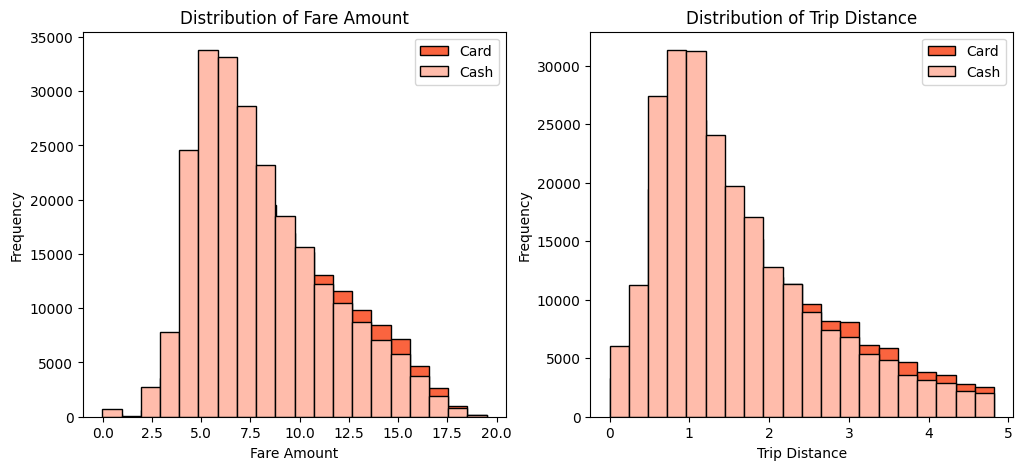

In [25]:
#Finding distribution of fareAmount and Trip Distance
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Distribution of Fare Amount")
plt.hist(df[df["payment_type"]=="Card"]["fare_amount"],histtype="barstacked",bins=20,edgecolor="k",color="#FA643F",label="Card")

plt.hist(df[df["payment_type"]=="Cash"]["fare_amount"],histtype="barstacked",bins=20,edgecolor="k",color="#FFBCAB",label="Cash")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")

plt.legend()

plt.subplot(1,2,2)
plt.title("Distribution of Trip Distance")
plt.hist(df[df["payment_type"]=="Card"]["trip_distance"],histtype="barstacked",bins=20,edgecolor="k",color="#FA643F",label="Card")

plt.hist(df[df["payment_type"]=="Cash"]["trip_distance"],histtype="barstacked",bins=20,edgecolor="k",color="#FFBCAB",label="Cash")
plt.legend()
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.show()



In [27]:
df.groupby("payment_type").agg({"fare_amount":["mean","std"],"trip_distance":["mean","std"]})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
3               5.693534  4.001534      1.224403  1.178175
4               6.997791  3.724447      1.393230  1.046926
5               5.500000  4.671566      1.733333  1.354730
Card            8.771994  3.539798      1.801689  1.085889
Cash            8.061147  3.401413      1.599141  1.020593

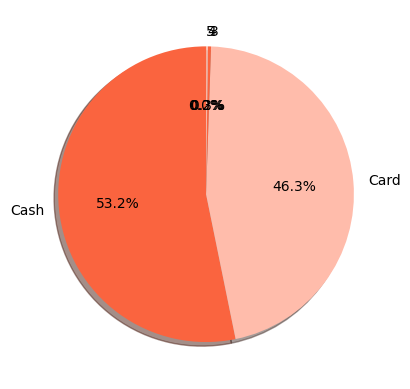

In [30]:
#percentage of passenger's count using cash and card
plt.pie(df["payment_type"].value_counts(normalize=True),labels=df["payment_type"].value_counts().index,startangle=90,autopct="%1.1f%%",shadow=True,colors=["#FA643F","#FFBCAB"])
plt.show()

In [31]:
df.head()

,passenger_count,trip_distance,fare_amount,payment_type,duration
0,1.0,1.71,9.0,Cash,9.833333
1,1.0,1.44,6.5,Cash,5.433333
2,5.0,3.45,12.0,Card,8.883333
3,1.0,2.11,10.5,Cash,12.716667
4,1.0,2.76,11.5,Cash,18.066667


In [40]:
# passenger_count= df.groupby(["payment_type", "passenger_count"]).size().reset_index(name="count")
# passenger_count

passenger_count=df.groupby(["payment_type", "passenger_count"])[["passenger_count"]].count()
passenger_count.rename(columns={'passenger_count':'count'},inplace=True)
passenger_count.reset_index(inplace=True)
passenger_count

,payment_type,passenger_count,count
0,3,1.0,1343
1,3,2.0,121
2,3,3.0,34
3,3,4.0,10
4,4,1.0,854
5,4,2.0,31
6,4,3.0,10
7,4,4.0,5
8,4,5.0,1
9,5,1.0,18


In [41]:
passenger_count['perc']=(passenger_count['count']/passenger_count['count'].sum())*100
passenger_count

,payment_type,passenger_count,count,perc
0,3,1.0,1343,0.298283
1,3,2.0,121,0.026874
2,3,3.0,34,0.007551
3,3,4.0,10,0.002221
4,4,1.0,854,0.189675
5,4,2.0,31,0.006885
6,4,3.0,10,0.002221
7,4,4.0,5,0.001111
8,4,5.0,1,0.000222
9,5,1.0,18,0.003998


In [52]:
#creating a new dataframe
df1 = pd.DataFrame(columns=["payment_type", 1, 2, 3, 4, 5])

df1["payment_type"] = ["Card", "Cash"]

df1.iloc[0, 1:] = passenger_count.iloc[0:5, -1].values
df1.iloc[1, 1:] = passenger_count.iloc[5:10, -1].values

df1

,payment_type,1,2,3,4,5
0,Card,0.298283,0.026874,0.007551,0.002221,0.189675
1,Cash,0.006885,0.002221,0.001111,0.000222,0.003998


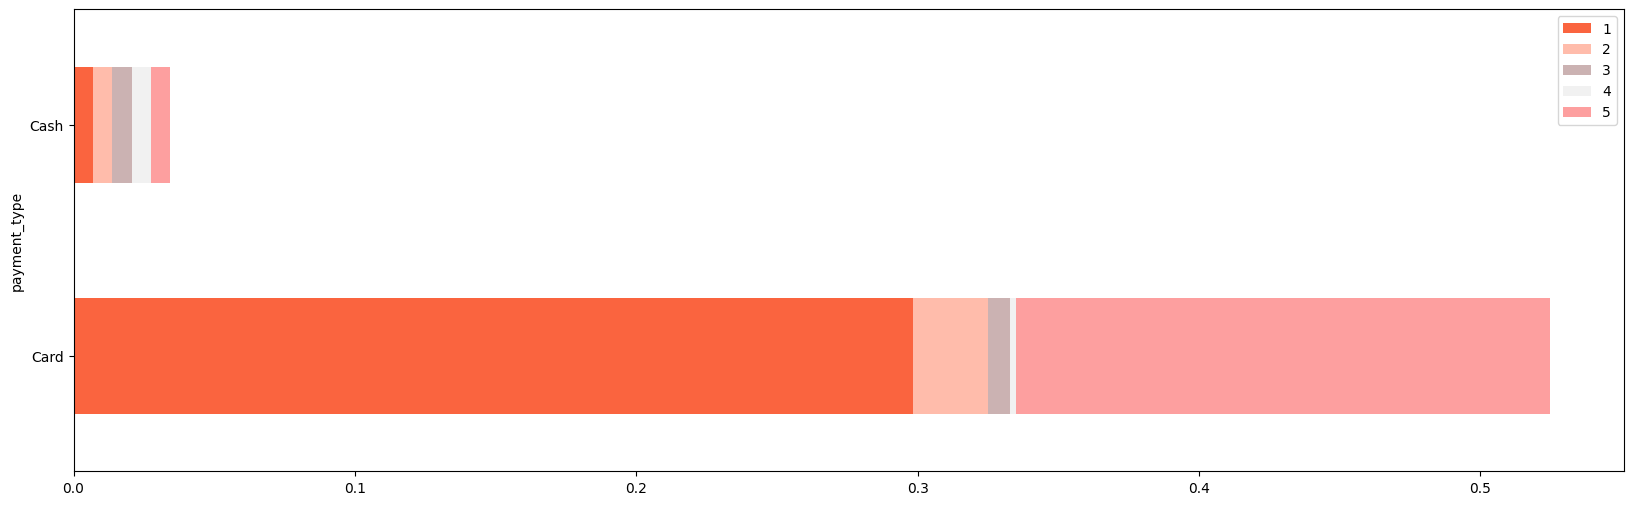

In [63]:
# plotting bar chart
fig,ax=plt.subplots(figsize=(20,6))
df.plot(x="payment_type",kind="barh",stacked=True,ax=ax,color=["#FA643F","#FFBCAB","#CBB2B2","#F1F1F1","#FD9F9F"])

# # Add percentage text
# for p in ax.patches:
#   width=p.get_width()
#   height=p.get_height()
#   x,y=p.get_xy()
#   ax.text(x+width/2,y+height/2,'{:.0f%}'.format(width),
#   horizontalalignment='center',
#   verticalalignment='center')

plt.show()



Null Hypothesis: There is a significant differnece betwenthe fare who uses credit and cash



> Add blockquote


ALternate Hypothesis:There is no  a significant differnece betwenthe fare who uses credit and cash

In [6]:
card_sample=df[df["payment_type"=="Card"]]['fare_amount']

cash_sample=df[df["payment_type"=="Cash"]]['fare_amount']

KeyError: False

In [7]:
t_stats,p_value=st.ttest_ind(a=card_sample,b=cash_sample,equal_var=False)
print("t_stats:",t_stats)
print("p_value:",p_value)

NameError: name 'card_sample' is not defined